In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Custom settings
plt.style.use('classic')
plt.rcParams.update({
    'figure.dpi': 100,
    'figure.figsize': (10, 6),
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.linewidth': 2,
    'axes.labelsize': 15,
    'axes.labelcolor': 'black',
    'savefig.facecolor': 'white',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'mathtext.fontset': 'cm',

    'savefig.bbox': 'tight',
    # Ticks
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 8,
    "ytick.major.size": 8,
    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.minor.width": 1.5,
    "ytick.minor.width": 1.5,
})



300 K (before): slope = 0.0183163, intercept = -0.320214, R² = 0.9983, V_T = 17.48 V, mu = 2.93e+06 cm²/Vs
300 K (after): slope = 0.00161912, intercept = -0.068877, R² = 0.9567, V_T = 42.54 V, mu = 2.59e+05 cm²/Vs


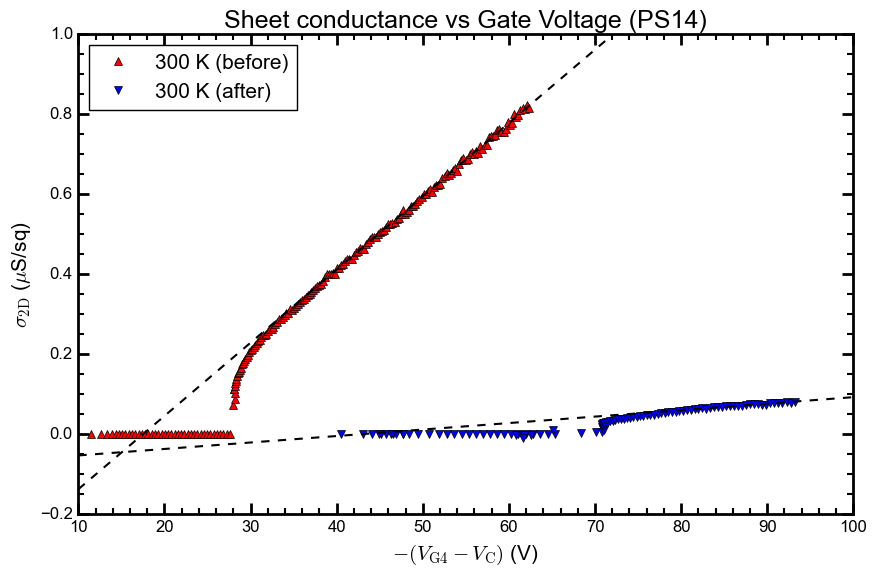

In [2]:
data1 = np.loadtxt("./Data-20262905/10.dat")
data2 = np.loadtxt("./Data-20262905/18.dat")
# data3 = np.loadtxt("./Data-20262905/09.dat")

C = 2e-9
A = 32e-6
Ci = C / A

datasets_IDS_VDS = [
    ("300 K (before)", data1, 'red', '^'),
    ("300 K (after)", data2, 'blue', 'v'),
    # ("300 K (300 nA)", data3, 'black', 'v'),
]

fit_ranges = {
    "300 K (before)": (40, 63),
    "300 K (after)": (80, 96),
}

for label, data, color, marker in datasets_IDS_VDS:
    V_GS = data[:, 0]
    I_DS = data[:, 2]
    V_DS = data[:, 3]
    V_C = 0.5 * (data[:, 4] + data[:, 5])
    V_12 = data[:, 6]
    sigma = -data[:, 7]

    window_size = 1
    window = np.ones(window_size) / window_size

    V_del_smooth = np.convolve(-(V_GS - V_C), window, mode='same')
    sigma_smooth = np.convolve(sigma, window, mode='same')
    sigma_plot = sigma_smooth * 1e6

    plt.plot(
        V_del_smooth,
        sigma_plot,
        label=label,
        color=color,
        marker=marker,
        markevery=1,
        ls='None',
        markersize=6,
    )

    fit_vmin, fit_vmax = fit_ranges[label]
    mask = (V_del_smooth >= fit_vmin) & (V_del_smooth <= fit_vmax)
    x_fit = V_del_smooth[mask]
    y_fit = sigma_plot[mask]

    if x_fit.size >= 2:
        slope, intercept = np.polyfit(x_fit, y_fit, 1)
        print(f"{label}: slope = {slope:.6g}, intercept = {intercept:.6g}, R² = {np.corrcoef(x_fit, y_fit)[0, 1]**2:.4f}, V_T = {-intercept/slope:.2f} V, mu = {slope / Ci*1e4:.2e} cm²/Vs")
        x_line = np.linspace(10, 100, 200)
        y_line = slope * x_line + intercept
        plt.plot(
            x_line,
            y_line,
            color='k',
            lw=1.5,
            linestyle='--',
        )

plt.xlabel(r"$-(V_\text{G4} - V_\text{C})$ (V)", fontsize=15)
plt.ylabel(r"$\sigma_\text{2D}$ ($\mu$S/sq)", fontsize=15)
# plt.xlim(10, 60)
plt.ylim(-0.2, 1)
plt.legend(frameon=True, loc='upper left', numpoints=1, fontsize=15)
plt.title("Sheet conductance vs Gate Voltage (PS14)", fontsize=18)
plt.savefig("vdP_sigma.eps", format='eps')
plt.show()

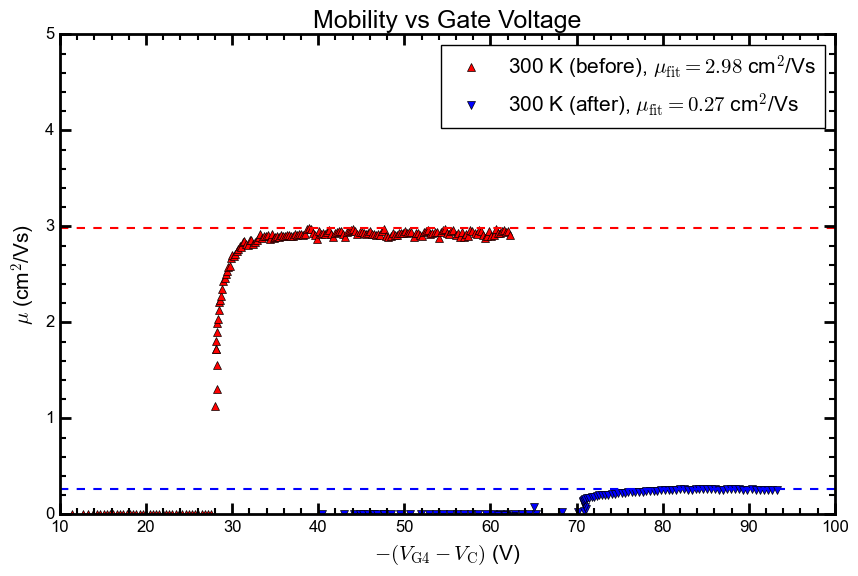

In [3]:
for label, data, color, marker in datasets_IDS_VDS:
    V_GS = data[:, 0]
    sigma = -data[:, 7]
    V_C = 0.5 * (data[:, 4] + data[:, 5])

    V_del_smooth = np.convolve(-(V_GS - V_C), window, mode='same')
    sigma_smooth = np.convolve(sigma, window, mode='same')
    sigma_plot = sigma_smooth * 1e6

    fit_vmin, fit_vmax = fit_ranges[label]
    mask = (V_del_smooth >= fit_vmin) & (V_del_smooth <= fit_vmax)
    x_fit = V_del_smooth[mask]
    y_fit = sigma_plot[mask]

    if x_fit.size >= 2:
        slope, intercept = np.polyfit(x_fit, y_fit, 1)
        V_T = -intercept / slope

        denom = Ci * (V_del_smooth - V_T)
        mu = np.full_like(V_del_smooth, np.nan, dtype=float)
        valid = np.isfinite(denom) & (np.abs(denom) > 1e-12)
        mu[valid] = (sigma_plot[valid] * 1e-6) / denom[valid] * 1e4  # cm^2/Vs

        plot_valid = np.isfinite(mu)
        mu_max = mu[plot_valid].max()
        plt.plot(
            V_del_smooth[plot_valid],
            mu[plot_valid],
            color=color,
            marker=marker,
            ls='None',
            markersize=6,
            label=fr"{label}, $\mu_\text{{fit}} = {mu_max:.2f}$ cm$^2$/Vs",
        )
        plt.axhline(mu_max, color=color, ls='--', lw=1.5)

plt.xlabel(r"$-(V_\text{G4} - V_\text{C})$ (V)", fontsize=15)
plt.ylabel(r"$\mu$ (cm$^2$/Vs)", fontsize=15)
plt.xlim(10, 100)
plt.ylim(0, 5)
plt.legend(frameon=True, numpoints=1, fontsize=15)
plt.title("Mobility vs Gate Voltage", fontsize=18)
plt.savefig("vdP_mobility.eps", format='eps')
plt.show()